# MLflow phase wall-time summary

This notebook reads the local `mlruns.db` tracking store with `mlflow`, computes wall time per run from `start_time` and `end_time`, and aggregates the total wall time by phase.

In [1]:
from pathlib import Path

import mlflow
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

workspace_root_candidates = [Path.cwd(), Path.cwd().parent]
workspace_root = next(
    (candidate for candidate in workspace_root_candidates if (candidate / "mlruns.db").exists()),
    Path.cwd(),
)
tracking_path = workspace_root / "mlruns.db"
tracking_uri = f"sqlite:///{tracking_path}"

mlflow.set_tracking_uri(tracking_uri)
experiments = mlflow.search_experiments()
if not experiments:
    raise RuntimeError(f"No MLflow experiments found in {tracking_path}.")

experiment = next((item for item in experiments if item.name == "speech-recognition"), None)
if experiment is None:
    experiment = next((item for item in experiments if item.name == "default"), experiments[0])

runs = mlflow.search_runs([experiment.experiment_id], output_format="pandas")
if runs.empty:
    raise RuntimeError(
        f"No runs found in experiment {experiment.name!r} (id={experiment.experiment_id})."
    )

phase_col = "params.phase.phase"
if phase_col not in runs.columns:
    raise RuntimeError(f"Missing expected phase column: {phase_col}.")

runs = runs.loc[runs[phase_col].notna()].copy()
if runs.empty:
    raise RuntimeError("No runs with a phase parameter were found.")

runs["start_time"] = pd.to_datetime(runs["start_time"], utc=True)
runs["end_time"] = pd.to_datetime(runs["end_time"], utc=True)
runs["wall_time_seconds"] = (runs["end_time"] - runs["start_time"]).dt.total_seconds()
runs["wall_time_hours"] = runs["wall_time_seconds"] / 3600.0

phase_order = ["phase_1", "phase_2", "phase_3", "phase_4"]
phase_labels = {
    phase: phase.replace("_", " ").title().replace("Phase ", "Phase ") for phase in phase_order
}
summary = (
    runs.groupby(phase_col, dropna=False)
    .agg(
        run_count=("run_id", "size"),
        total_wall_time_hours=("wall_time_hours", "sum"),
        mean_wall_time_hours=("wall_time_hours", "mean"),
    )
    .reindex(phase_order)
)
summary.insert(0, "phase_label", summary.index.map(phase_labels))
summary["total_wall_time_days"] = summary["total_wall_time_hours"] / 24.0
summary["share_of_total"] = (
    summary["total_wall_time_hours"] / summary["total_wall_time_hours"].sum()
)
display(
    summary.style.format(
        {
            "total_wall_time_hours": "{:,.2f}",
            "mean_wall_time_hours": "{:,.2f}",
            "total_wall_time_days": "{:,.2f}",
            "share_of_total": "{:.1%}",
        }
    )
)

,phase_label,run_count,total_wall_time_hours,mean_wall_time_hours,total_wall_time_days,share_of_total
params.phase.phase,,,,,,
phase_1,Phase 1,30,106.22,3.54,4.43,32.2%
phase_2,Phase 2,24,89.75,3.74,3.74,27.2%
phase_3,Phase 3,43,36.23,0.84,1.51,11.0%
phase_4,Phase 4,36,97.22,2.70,4.05,29.5%


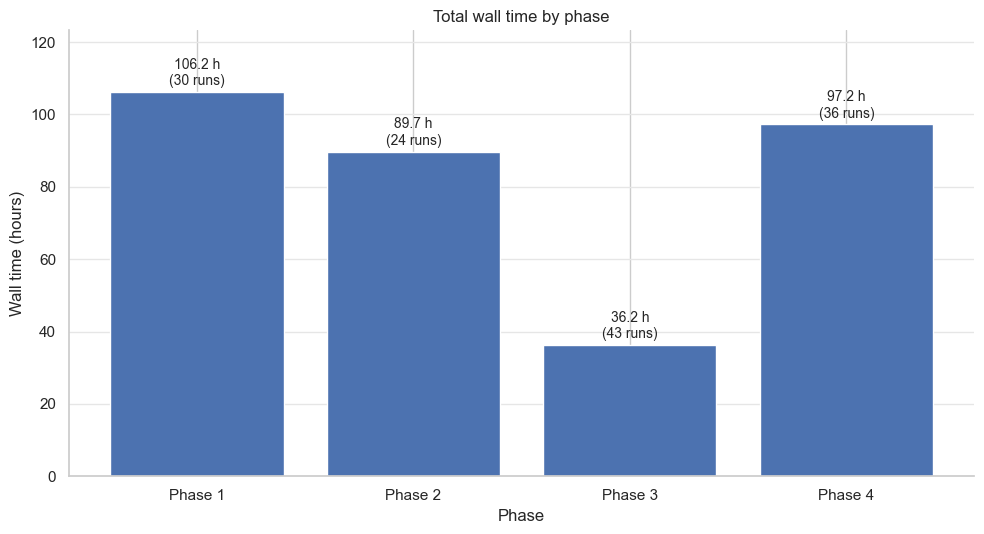

Saved plot to /Users/pawelp/Desktop/education/pw/deepl/speech-recognition/notebooks/plots/mlflow_phase_wall_time_summary.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_dir = workspace_root / "notebooks" / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)
plot_path = plot_dir / "mlflow_phase_wall_time_summary.png"

plot_data = summary.dropna(subset=["total_wall_time_hours"]).copy()
plot_data = plot_data.sort_values("phase_label")

fig, ax = plt.subplots(figsize=(10, 5.5))
bar_color = sns.color_palette("deep")[0]
bars = ax.bar(plot_data["phase_label"], plot_data["total_wall_time_hours"], color=bar_color)
ax.set_title("Total wall time by phase")
ax.set_xlabel("Phase")
ax.set_ylabel("Wall time (hours)")
ax.grid(axis="y", color="0.9", linewidth=1)
sns.despine(ax=ax, top=True, right=True)

for bar, value, run_count in zip(
    bars, plot_data["total_wall_time_hours"], plot_data["run_count"], strict=False
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(plot_data["total_wall_time_hours"]) * 0.01,
        f"{value:,.1f} h\n({int(run_count)} runs)",
        va="bottom",
        ha="center",
        fontsize=10,
    )

ax.set_ylim(0, max(plot_data["total_wall_time_hours"]) * 1.16)
fig.tight_layout()
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved plot to {plot_path}")

In [3]:
import sqlite3

import pandas as pd
from IPython.display import display

step_metric = "step"
epoch_elapsed_metric = "epoch_elapsed_ms"

with sqlite3.connect(tracking_path) as connection:
    metric_frame = pd.read_sql_query(
        "select run_uuid, key, step, value from metrics where key in (?, ?)",
        connection,
        params=(step_metric, epoch_elapsed_metric),
    )

step_frame = (
    metric_frame.loc[metric_frame["key"] == step_metric]
    .groupby("run_uuid", as_index=False)
    .agg(final_step=("step", "max"))
)
time_frame = (
    metric_frame.loc[metric_frame["key"] == epoch_elapsed_metric]
    .groupby("run_uuid", as_index=False)
    .agg(final_epoch_elapsed_ms=("value", "max"))
)

speed_frame = step_frame.merge(time_frame, on="run_uuid", how="inner")
speed_frame = speed_frame.dropna(subset=["final_step", "final_epoch_elapsed_ms"]).copy()
speed_frame["avg_step_time_ms"] = speed_frame["final_epoch_elapsed_ms"] / speed_frame["final_step"]
speed_frame["avg_steps_per_second"] = 1000.0 / speed_frame["avg_step_time_ms"]

run_family_map = runs.set_index("run_id")["params.model.family"]
architecture_order = ["ast", "convnext", "mlp_mixer", "ssamba", "xlstm", "unknown"]
architecture_labels = {
    "ast": "AST",
    "convnext": "ConvNeXt",
    "mlp_mixer": "MLP-Mixer",
    "ssamba": "SSAMBA",
    "xlstm": "xLSTM",
    "unknown": "Unknown",
}
speed_frame["model_family"] = speed_frame["run_uuid"].map(run_family_map).fillna("unknown")
speed_frame["model_family"] = speed_frame["model_family"].fillna("unknown")
speed_frame["model_family"] = speed_frame["model_family"].where(
    speed_frame["model_family"].isin(architecture_order), "unknown"
)

speed_summary = (
    speed_frame.groupby("model_family")
    .agg(
        run_count=("run_uuid", "size"),
        mean_step_time_ms=("avg_step_time_ms", "mean"),
        median_step_time_ms=("avg_step_time_ms", "median"),
        mean_steps_per_second=("avg_steps_per_second", "mean"),
        total_steps=("final_step", "sum"),
    )
    .reindex(architecture_order)
)
speed_summary.insert(0, "architecture_label", speed_summary.index.map(architecture_labels))

display(
    speed_summary.style.format(
        {
            "mean_step_time_ms": "{:,.2f}",
            "median_step_time_ms": "{:,.2f}",
            "mean_steps_per_second": "{:,.2f}",
            "total_steps": "{:,.0f}",
        }
    )
)

,architecture_label,run_count,mean_step_time_ms,median_step_time_ms,mean_steps_per_second,total_steps
model_family,,,,,,
ast,AST,36,6.26,4.86,210.17,"823,484"
convnext,ConvNeXt,45,5.55,3.68,262.67,"1,011,138"
mlp_mixer,MLP-Mixer,24,26.84,27.06,49.74,"300,696"
ssamba,SSAMBA,1,"13,199.47","13,199.47",0.08,700
xlstm,xLSTM,27,56.62,49.75,20.94,"333,971"
unknown,Unknown,6,36.35,18.00,197.01,"104,179"
